Loaded 47,354 rows × 27 columns
Plotting 23 variables in a 6×4 grid


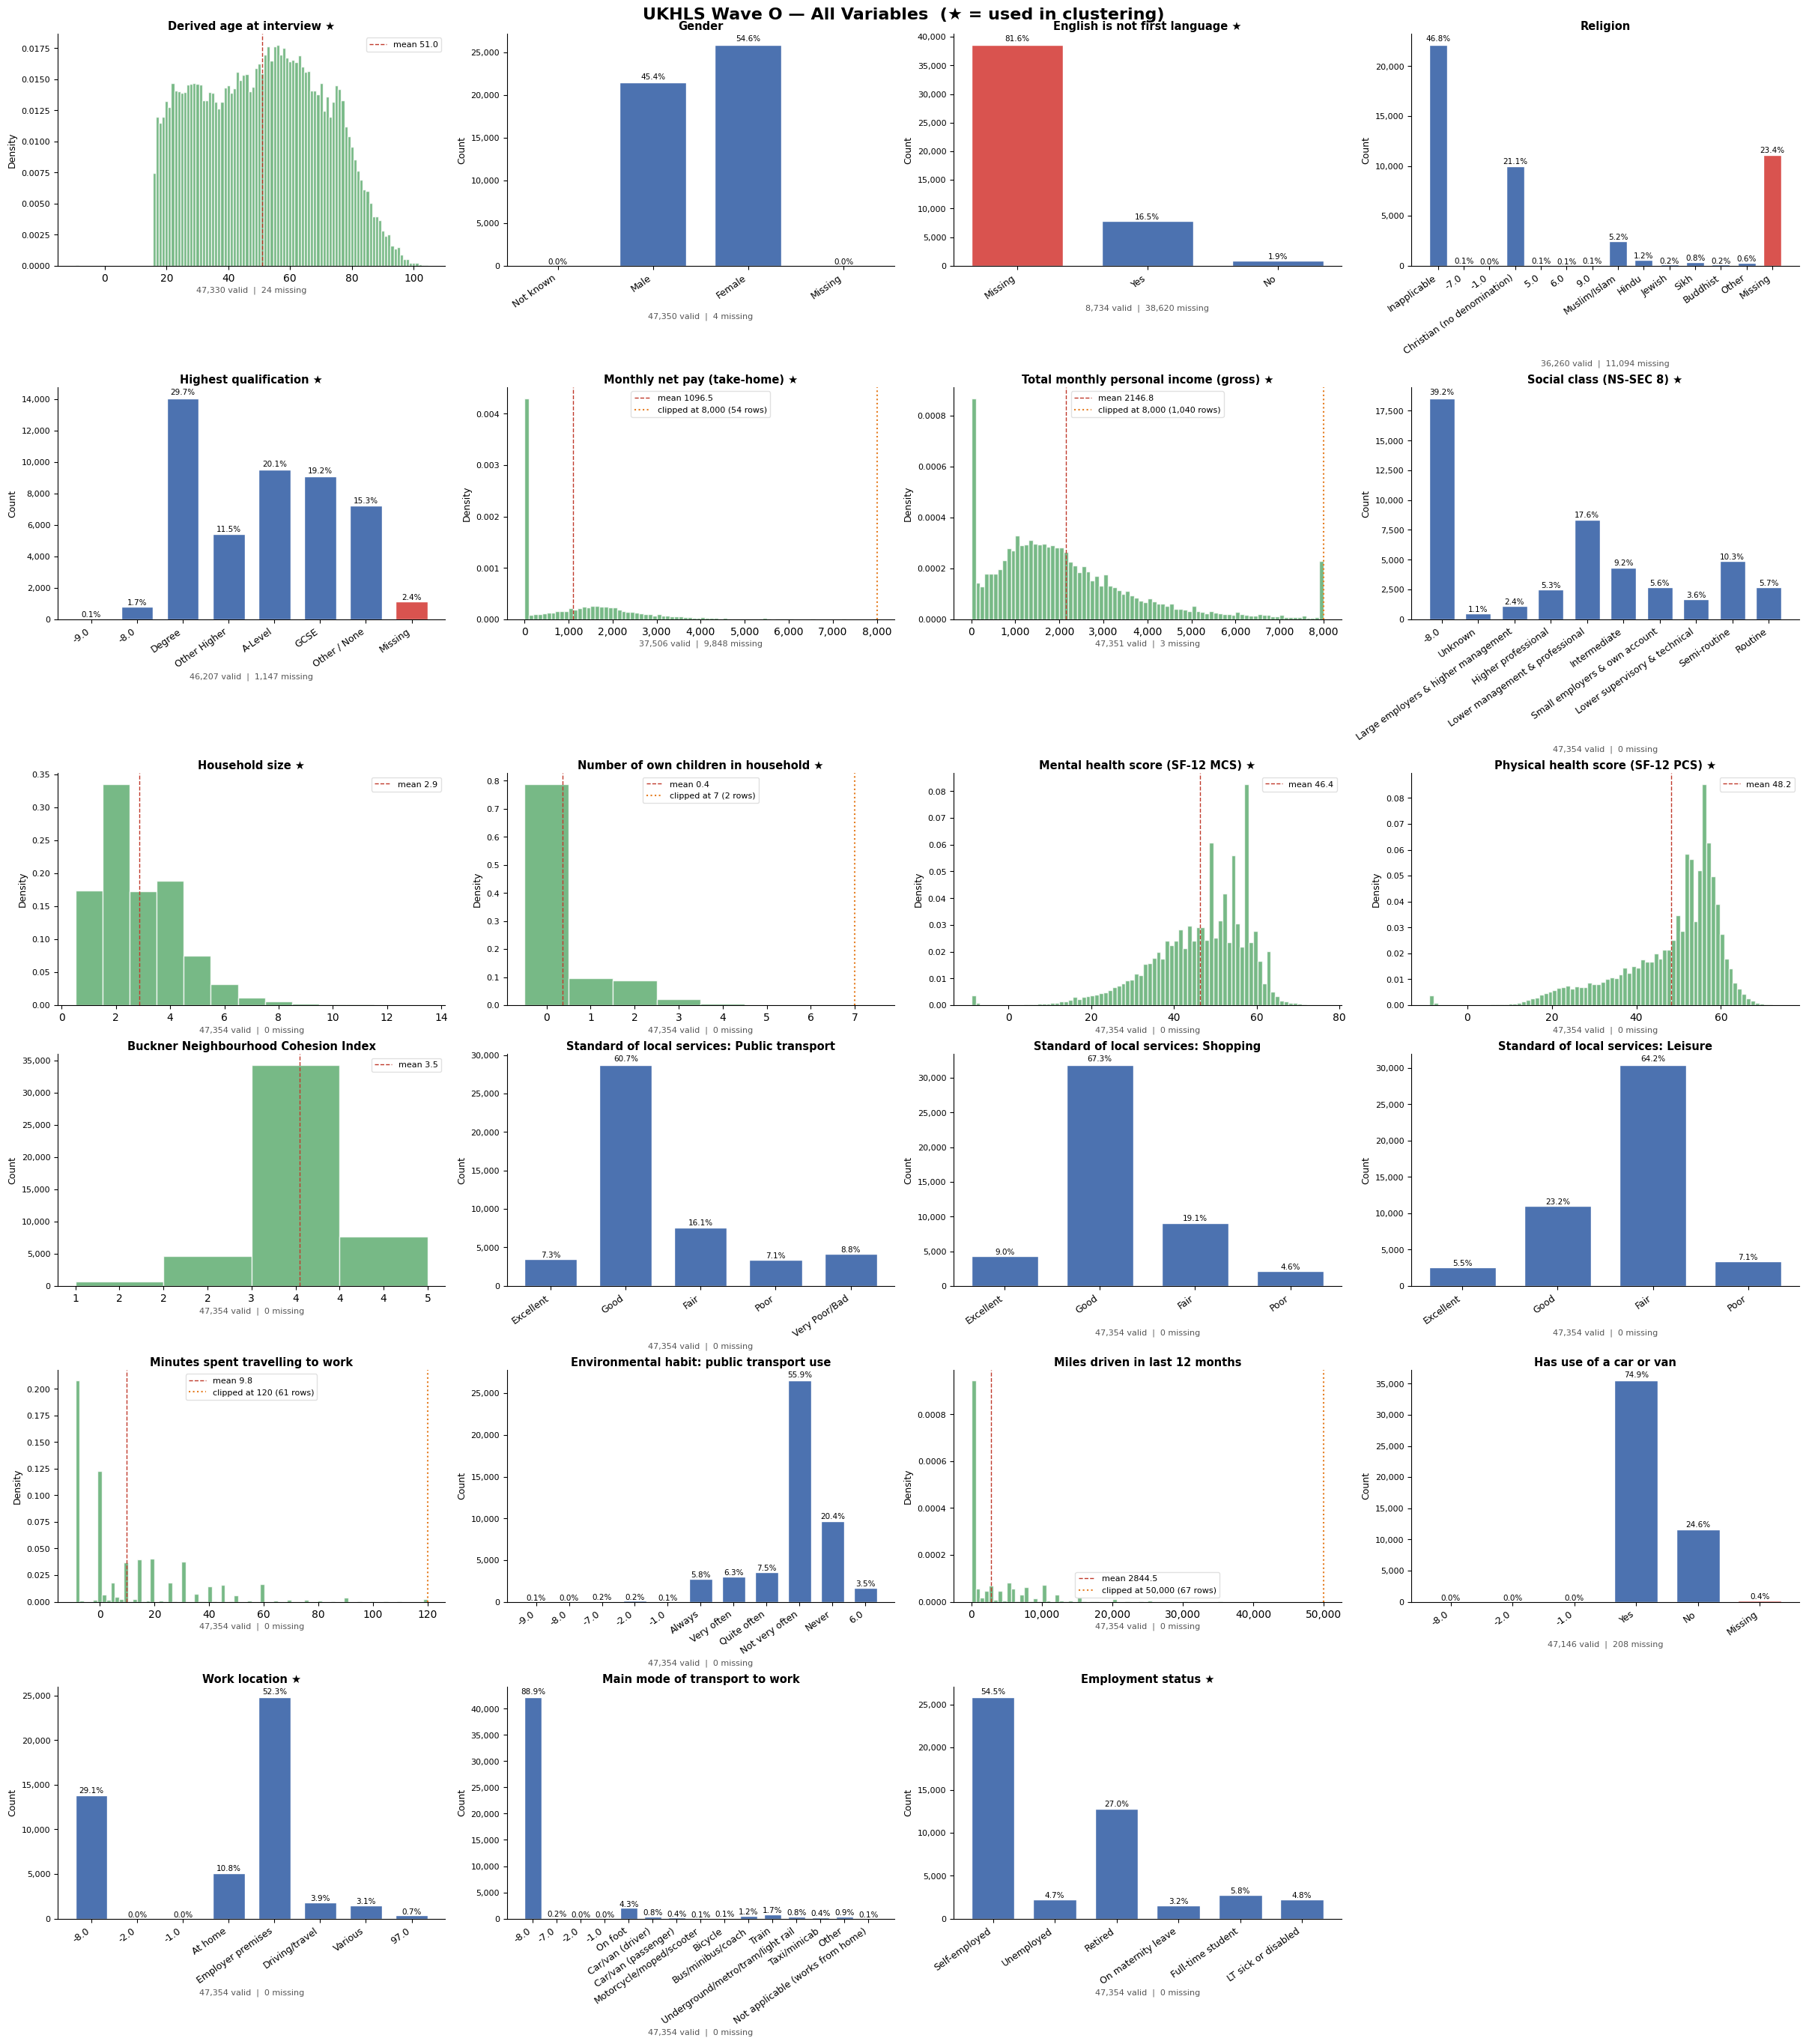

Saved to ../data/3_backfill_ukhls_waves/variable_distributions.png


In [2]:
# Variable Distribution Viewer
# Loads o_indresp_backfilled.pkl and plots every variable using
# human-readable labels and category names from config_variables.py

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_processing.config_variables as _ukhls_vars
importlib.reload(_ukhls_vars)  # pick up any edits made since kernel started

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

VARIABLES        = _ukhls_vars.VARIABLES
CATEGORICAL_VARS = _ukhls_vars.CATEGORICAL_VARS
CONTINUOUS_VARS  = _ukhls_vars.CONTINUOUS_VARS

# ── Config ────────────────────────────────────────────────────────────────────
WAVE          = "o"
PICKLE_PATH   = "../data/3_backfill_ukhls_waves/o_indresp_backfilled.pkl"
COLS_PER_ROW  = 4
BAR_COLOR     = "#4C72B0"
MISSING_COLOR = "#d9534f"
HIST_COLOR    = "#55A868"
CLIP_COLOR    = "#e67e22"   # annotation colour for clip/floor markers

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_pickle(PICKLE_PATH)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

# ── Build the ordered plot list ───────────────────────────────────────────────
plot_specs = []
for base_code, var_def in VARIABLES.items():
    if base_code == "pidp":
        continue

    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        continue

    plot_specs.append(dict(
        col        = col,
        label      = var_def["label"],
        is_cat     = var_def["categorical"],
        categories = var_def["categories"],
        is_cluster = var_def["cluster"],
        clip       = var_def.get("clip"),       # upper bound or None
        floor      = var_def.get("floor"),      # lower bound or None
        recode     = var_def.get("recode"),     # {old_val: new_val} or None
        bin_width  = var_def.get("bin_width"),  # fixed histogram bin width or None
    ))

n_plots = len(plot_specs)
n_cols  = COLS_PER_ROW
n_rows  = (n_plots + n_cols - 1) // n_cols

print(f"Plotting {n_plots} variables in a {n_rows}×{n_cols} grid")

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    constrained_layout=True,
)
axes_flat = axes.flatten()

for idx, spec in enumerate(plot_specs):
    ax   = axes_flat[idx]
    col  = spec["col"]
    data = df[col]

    flag      = " ★" if spec["is_cluster"] else ""
    title     = spec["label"] + flag
    n_valid   = data.notna().sum()
    n_missing = data.isna().sum()
    subtitle  = f"{n_valid:,} valid  |  {n_missing:,} missing"

    # ── Categorical: bar chart (skipped when bin_width is set) ────────────
    if (spec["is_cat"] and not spec["bin_width"]) or (data.nunique(dropna=True) <= 12 and spec["categories"] is not None):
        cat_map = spec["categories"] or {}

        # Apply recode before counting (e.g. merging category values)
        if spec["recode"]:
            data = data.replace(spec["recode"])

        # Include NaN as an explicit "Missing" bar (sorted last)
        raw_counts = data.value_counts(dropna=False).sort_index(na_position="last")
        labels_x, counts_y, colors = [], [], []

        for raw_val, cnt in raw_counts.items():
            if pd.isna(raw_val):
                labels_x.append("Missing")
                colors.append(MISSING_COLOR)
            else:
                try:
                    key = float(raw_val)
                except (ValueError, TypeError):
                    key = raw_val
                labels_x.append(cat_map.get(key, str(raw_val)))
                colors.append(BAR_COLOR)
            counts_y.append(cnt)

        bars  = ax.bar(range(len(labels_x)), counts_y, color=colors, edgecolor="white", width=0.7)
        total = sum(counts_y)

        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x, rotation=35, ha="right", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.set_ylabel("Count", fontsize=9)

        for bar, cnt in zip(bars, counts_y):
            pct = 100 * cnt / total if total else 0
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{pct:.1f}%",
                ha="center", va="bottom", fontsize=7.5,
            )

    # ── Continuous: histogram ─────────────────────────────────────────────
    else:
        vals = pd.to_numeric(data, errors="coerce").dropna()
        if len(vals) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        else:
            floor_val = spec["floor"]
            clip_val  = spec["clip"]
            bin_width = spec["bin_width"]
            clipped   = False
            n_clipped = 0

            # Apply recode first (e.g. 9 → 5 for hiqual_dv)
            if spec["recode"]:
                vals = vals.replace(spec["recode"])

            if floor_val is not None:
                vals = vals.clip(lower=floor_val)
            if clip_val is not None and vals.max() > clip_val:
                n_clipped = int((vals > clip_val).sum())
                vals      = vals.clip(upper=clip_val)
                clipped   = True

            val_min   = vals.min()
            val_max   = vals.max()
            val_range = val_max - val_min

            if bin_width is not None:
                bins = np.arange(val_min, val_max + bin_width, bin_width)
            elif ((vals % 1) == 0).all() and val_range <= 120:
                bins = np.arange(val_min - 0.5, val_max + 1.5, 1)
            else:
                bins = min(80, max(20, len(vals) // 300))

            use_density = bin_width is None
            ax.hist(vals, bins=bins, color=HIST_COLOR, edgecolor="white", density=use_density, alpha=0.8)

            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
            ax.set_ylabel("Density" if use_density else "Count", fontsize=9)
            if not use_density:
                ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                       label=f"mean {vals.mean():.1f}")

            if clipped:
                ax.axvline(clip_val, color=CLIP_COLOR, linestyle=":", linewidth=1.5,
                           label=f"clipped at {clip_val:,} ({n_clipped:,} rows)")

            ax.legend(fontsize=8, framealpha=0.6)

    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=4)
    ax.set_xlabel(subtitle, fontsize=8, labelpad=3, color="#555")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# ── Hide unused axes ──────────────────────────────────────────────────────────
for unused_ax in axes_flat[n_plots:]:
    unused_ax.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — All Variables  (★ = used in clustering)",
    fontsize=16, fontweight="bold", y=1.005,
)

plt.savefig("../data/3_backfill_ukhls_waves/variable_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ../data/3_backfill_ukhls_waves/variable_distributions.png")
